# Seasonal Agriculture Performance Analysis

## Project Overview

This project analyzes agricultural performance across different seasons using data analytics techniques.

The analysis focuses on seasonal variations in crop yield, production, resource usage, environmental conditions, revenue, profitability, and disease/pest risk.

The objective is to identify meaningful seasonal patterns, compare agricultural performance, and develop evidence-based insights and recommendations for better seasonal agricultural planning.

In [105]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Dataset Overview

The dataset contains 4,000 agricultural records and 28 variables covering farming activities, environmental conditions, resource usage, crop production, and economic performance.

The dataset includes information about states, districts, crops, seasons, rainfall, temperature, soil conditions, irrigation methods, yield, production, market prices, revenue, costs, profit, water usage, and disease/pest risk.

In [46]:
# Load the dataset

file_path = "/content/seasonal_agriculture_performance_dataset (2).csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset loaded successfully!
Number of Rows: 4000
Number of Columns: 28


In [47]:
# Display first 5 rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [48]:
# Display last 5 rows

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [49]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [50]:
# Display all column names

print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Columns in the dataset:

1 - Farm_ID
2 - State
3 - District
4 - Crop
5 - Season
6 - Farm_Area_Hectares
7 - Rainfall_mm
8 - Avg_Temperature_C
9 - Humidity_pct
10 - Sunlight_Hours_Day
11 - Soil_pH
12 - Soil_Moisture_pct
13 - Nitrogen_kg_ha
14 - Phosphorus_kg_ha
15 - Potassium_kg_ha
16 - Irrigation_Method
17 - Fertilizer_kg_ha
18 - Pesticide_Litre_ha
19 - Seed_Quality_Score
20 - Yield_Tonnes_Ha
21 - Production_Tonnes
22 - Market_Price_INR_Tonne
23 - Total_Cost_INR
24 - Revenue_INR
25 - Profit_INR
26 - Water_Used_m3
27 - Water_Efficiency_t_per_1000m3
28 - Disease_Pest_Risk_pct


In [51]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [52]:
# Summary of categorical columns

df.describe(include="object").T

,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


## 2. Data Cleaning and Preparation

The dataset was examined for missing values, duplicate records, data types, and unique values.

Data quality checks were performed before conducting further analysis to ensure that the results were based on a reliable dataset.

In [53]:
# Check missing values

missing = df.isnull().sum()

missing_percentage = (df.isnull().mean() * 100)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing_Count",
    ascending=False
)

missing_summary

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8
Farm_ID,0,0.0
Crop,0,0.0
District,0,0.0
Farm_Area_Hectares,0,0.0
Season,0,0.0
Avg_Temperature_C,0,0.0
Humidity_pct,0,0.0


In [ ]:
# Show only columns having missing values

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [55]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [54]:
# Remove duplicate rows if any

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (4000, 28)


In [56]:
# Display data types

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str)
})

dtype_summary

,Column,Data_Type
Farm_ID,Farm_ID,object
State,State,object
District,District,object
Crop,Crop,object
Season,Season,object
Farm_Area_Hectares,Farm_Area_Hectares,float64
Rainfall_mm,Rainfall_mm,float64
Avg_Temperature_C,Avg_Temperature_C,float64
Humidity_pct,Humidity_pct,float64
Sunlight_Hours_Day,Sunlight_Hours_Day,float64


In [57]:
# Number of unique values in each column

unique_values = df.nunique().sort_values()

unique_values

,0
Season,3
Irrigation_Method,4
Crop,8
State,8
District,10
Seed_Quality_Score,36
Sunlight_Hours_Day,71
Avg_Temperature_C,204
Soil_pH,313
Soil_Moisture_pct,343


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) was performed to understand how agricultural performance varies across seasons.

The analysis examines yield, production, economic outcomes, resource usage, environmental conditions, and disease/pest risk.

In [58]:
# Check unique seasons

print("Seasons available in the dataset:")

print(df["Season"].unique())

Seasons available in the dataset:
['Kharif' 'Rabi' 'Zaid']


In [59]:
# Count records for each season

season_counts = df["Season"].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


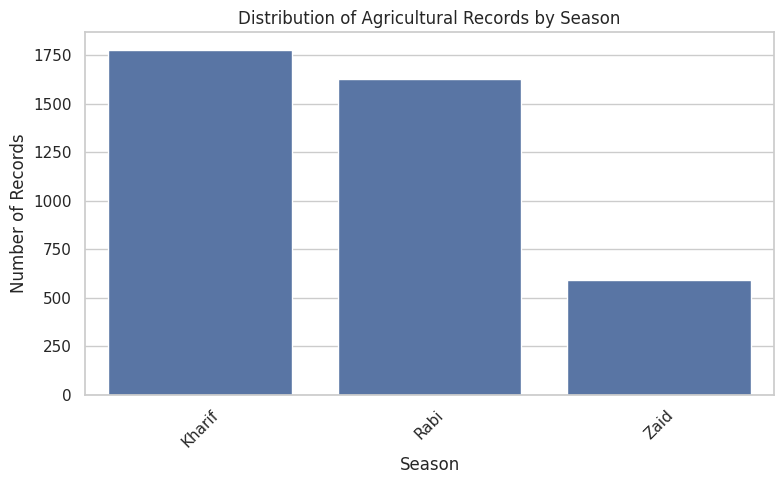

In [60]:
# Visualize number of records by season

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Season"
)

plt.title("Distribution of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Seasonal Performance Analysis

Season-wise comparisons were conducted to identify differences in agricultural productivity and performance.

Key indicators include average yield, total production, revenue, profit, and water usage.

In [61]:
# Average yield by season

season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(
    ascending=False
)

print("Average Yield by Season:")
print(season_yield)

Average Yield by Season:
Season
Kharif    5.643973
Rabi      5.080498
Zaid      4.665942
Name: Yield_Tonnes_Ha, dtype: float64


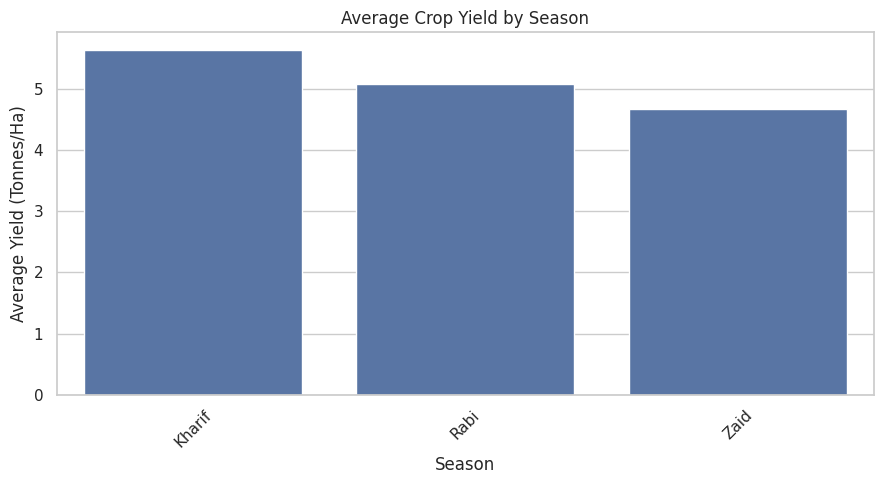

In [62]:
# Visualize average yield by season

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_yield.index,
    y=season_yield.values
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
# Total production by season

season_production = df.groupby("Season")["Production_Tonnes"].sum().sort_values(
    ascending=False
)

print("Total Production by Season:")
print(season_production)

Total Production by Season:
Season
Kharif    82387.61
Rabi      67498.88
Zaid      23098.35
Name: Production_Tonnes, dtype: float64


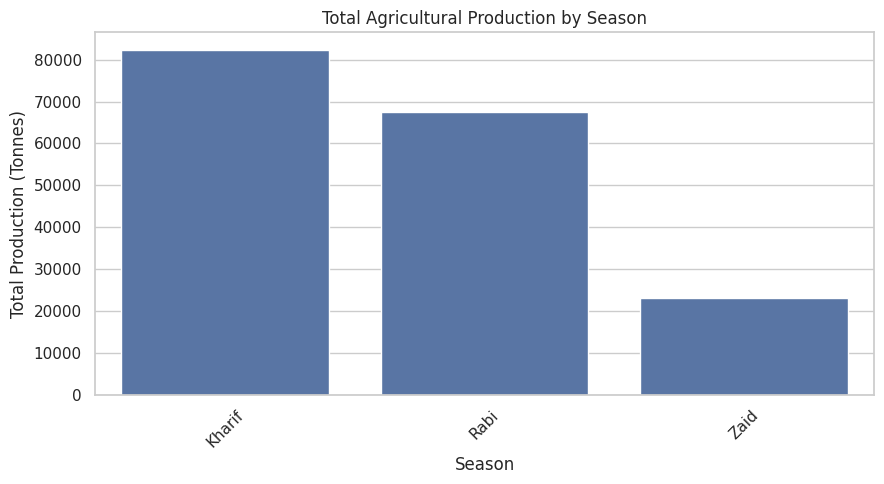

In [64]:
# Visualize total production by season

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_production.index,
    y=season_production.values
)

plt.title("Total Agricultural Production by Season")
plt.xlabel("Season")
plt.ylabel("Total Production (Tonnes)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [65]:
# Total revenue by season

season_revenue = df.groupby("Season")["Revenue_INR"].sum().sort_values(
    ascending=False
)

print("Total Revenue by Season:")
print(season_revenue)

Total Revenue by Season:
Season
Kharif    1264369200
Rabi       978682881
Zaid       308388111
Name: Revenue_INR, dtype: int64


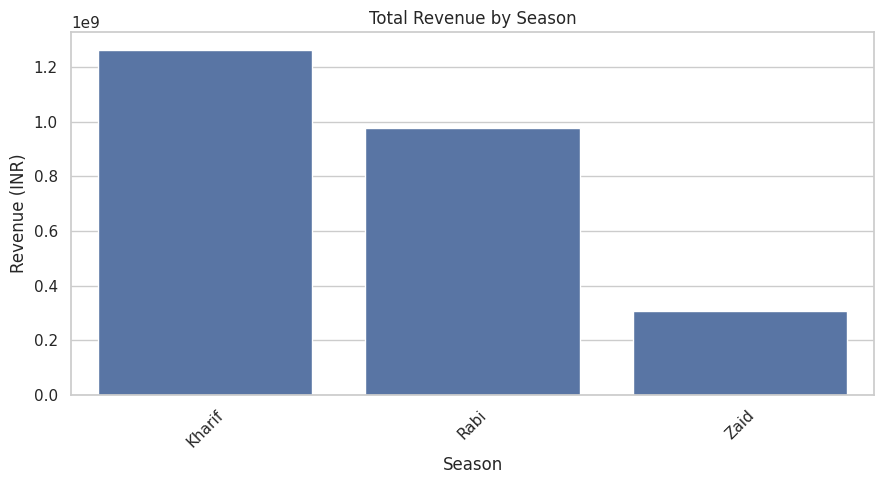

In [66]:
# Visualize revenue by season

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_revenue.index,
    y=season_revenue.values
)

plt.title("Total Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue (INR)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
# Total profit by season

season_profit = df.groupby("Season")["Profit_INR"].sum().sort_values(
    ascending=False
)

print("Total Profit by Season:")
print(season_profit)

Total Profit by Season:
Season
Kharif    318289158
Rabi      142670768
Zaid      -14734066
Name: Profit_INR, dtype: int64


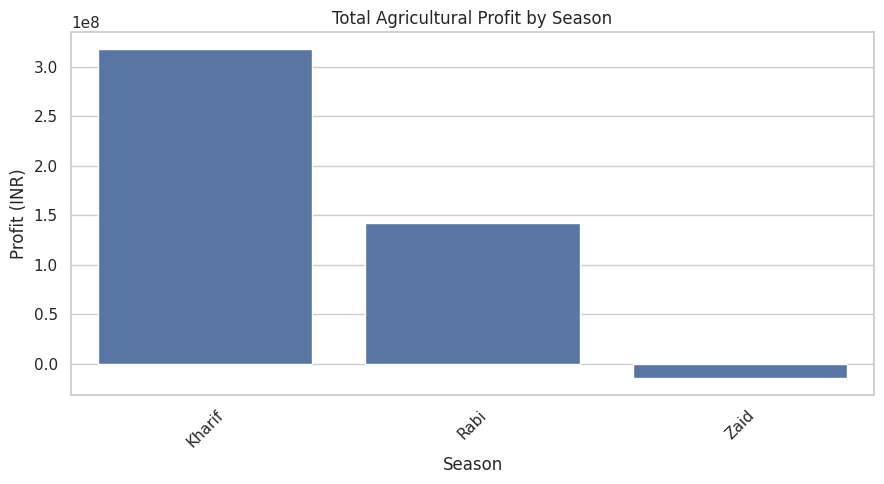

In [68]:
# Visualize profit by season

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_profit.index,
    y=season_profit.values
)

plt.title("Total Agricultural Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [69]:
# Average water usage by season

season_water = df.groupby("Season")["Water_Used_m3"].mean().sort_values(
    ascending=False
)

print("Average Water Usage by Season:")
print(season_water)

Average Water Usage by Season:
Season
Zaid      6419.893939
Kharif    6102.201237
Rabi      5846.987093
Name: Water_Used_m3, dtype: float64


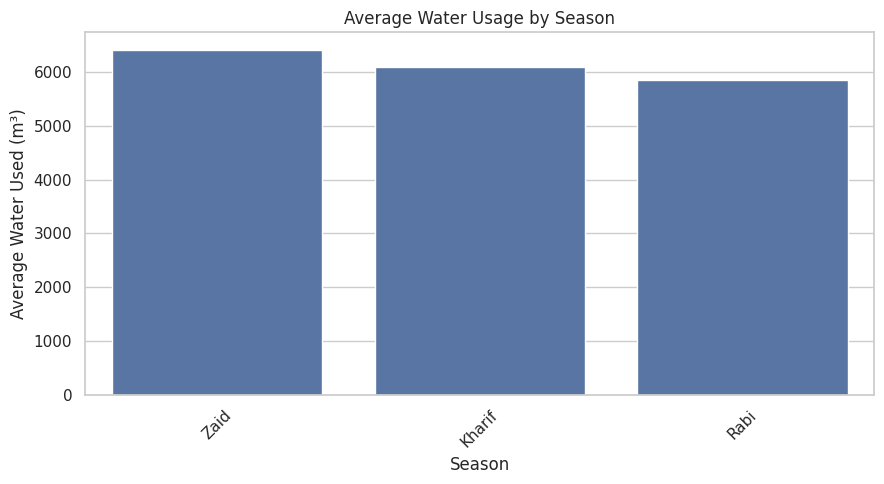

In [70]:
# Visualize average water usage by season

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_water.index,
    y=season_water.values
)

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Environmental Conditions

Environmental factors such as rainfall, average temperature, and soil moisture were analyzed across seasons to understand their relationship with agricultural performance.

In [71]:
# Average rainfall by season

season_rainfall = df.groupby("Season")["Rainfall_mm"].mean().sort_values(
    ascending=False
)

print("Average Rainfall by Season:")
print(season_rainfall)

Average Rainfall by Season:
Season
Kharif    852.084205
Rabi      436.000124
Zaid      299.421784
Name: Rainfall_mm, dtype: float64


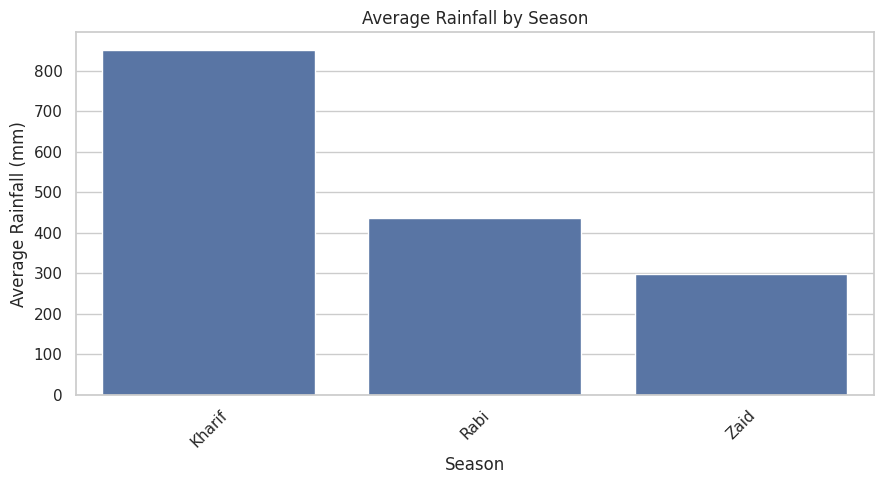

In [72]:
# Visualize rainfall by season

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_rainfall.index,
    y=season_rainfall.values
)

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Average Rainfall (mm)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [73]:
# Average temperature by season

season_temperature = df.groupby("Season")["Avg_Temperature_C"].mean().sort_values(
    ascending=False
)

print("Average Temperature by Season:")
print(season_temperature)

Average Temperature by Season:
Season
Zaid      31.042088
Kharif    28.454019
Rabi      23.489183
Name: Avg_Temperature_C, dtype: float64


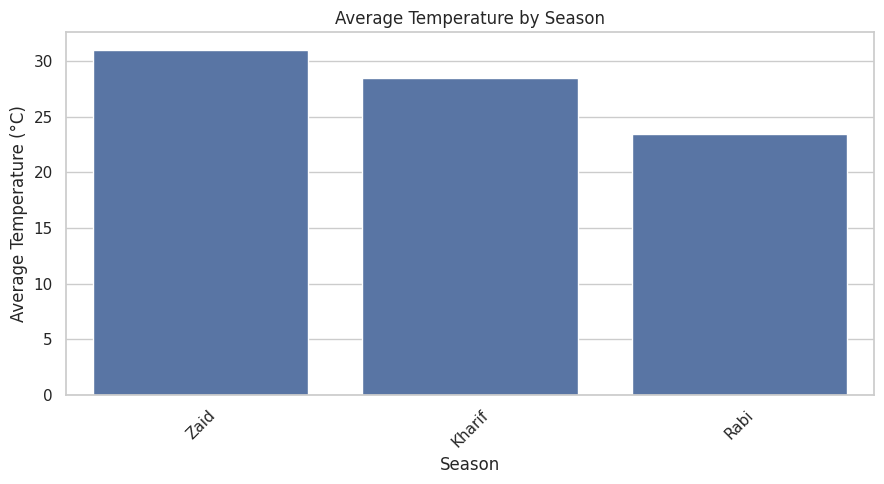

In [74]:
# Visualize temperature by season

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_temperature.index,
    y=season_temperature.values
)

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Average soil moisture by season

season_soil = df.groupby("Season")["Soil_Moisture_pct"].mean().sort_values(
    ascending=False
)

print("Average Soil Moisture by Season:")
print(season_soil)

Average Soil Moisture by Season:
Season
Kharif    31.198410
Rabi      24.050620
Zaid      19.170085
Name: Soil_Moisture_pct, dtype: float64


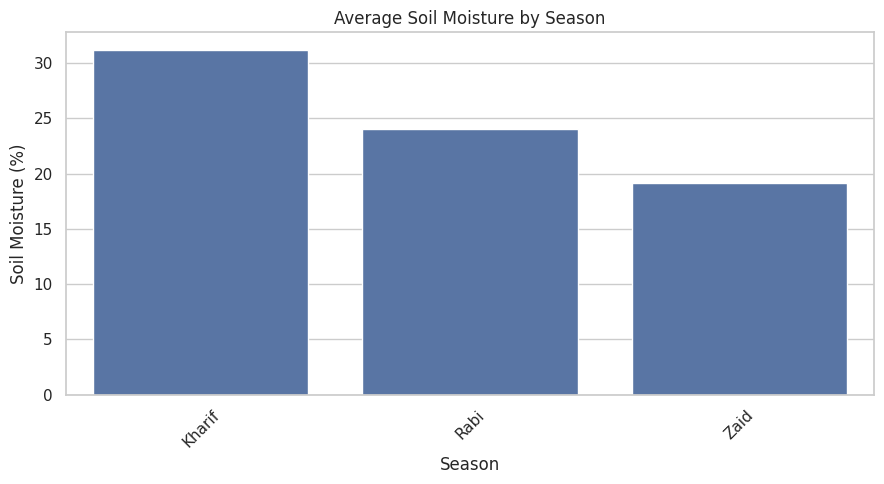

In [75]:
# Visualize soil moisture by season

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_soil.index,
    y=season_soil.values
)

plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [76]:
# Irrigation methods used in different seasons

irrigation_season = pd.crosstab(
    df["Season"],
    df["Irrigation_Method"]
)

irrigation_season

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


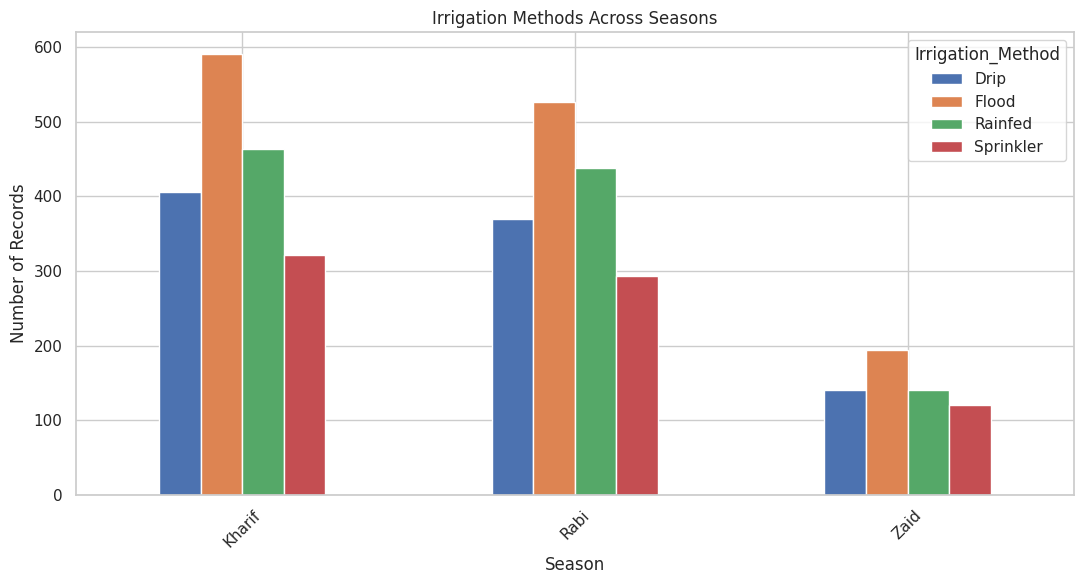

In [77]:
# Visualize irrigation methods across seasons

irrigation_season.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Irrigation Methods Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
# Top 10 crops based on total production

crop_production = df.groupby("Crop")["Production_Tonnes"].sum().sort_values(
    ascending=False
)

crop_production.head(10)

,Production_Tonnes
Crop,
Sugarcane,119685.97
Rice,13309.15
Maize,12001.40
Wheat,10348.30
Chilli,5101.75
Cotton,4773.10
Groundnut,4094.07
Pulses,3671.10


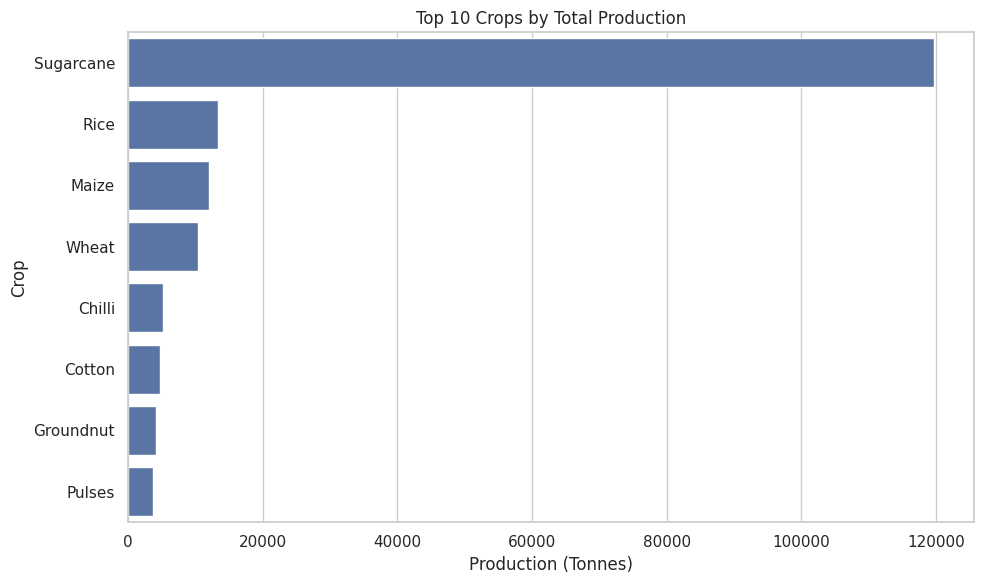

In [79]:
# Visualize top 10 crops by production

top_crops = crop_production.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_crops.values,
    y=top_crops.index
)

plt.title("Top 10 Crops by Total Production")
plt.xlabel("Production (Tonnes)")
plt.ylabel("Crop")

plt.tight_layout()
plt.show()

In [80]:
# Total production by state

state_production = df.groupby("State")["Production_Tonnes"].sum().sort_values(
    ascending=False
)

state_production.head(10)

,Production_Tonnes
State,
Punjab,25280.82
Gujarat,23586.01
Karnataka,23341.30
Maharashtra,22519.83
Telangana,20255.16
Tamil Nadu,19807.58
Andhra Pradesh,19527.06
Madhya Pradesh,18667.08


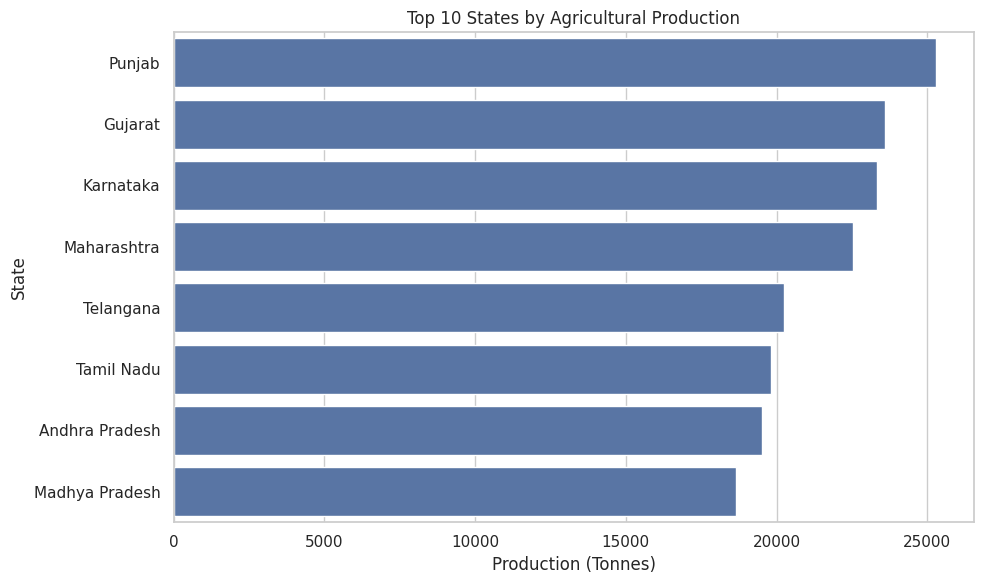

In [81]:
# Top 10 states by production

top_states = state_production.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Agricultural Production")
plt.xlabel("Production (Tonnes)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [82]:
# Average disease and pest risk by season

season_risk = df.groupby("Season")["Disease_Pest_Risk_pct"].mean().sort_values(
    ascending=False
)

print("Average Disease/Pest Risk by Season:")
print(season_risk)

Average Disease/Pest Risk by Season:
Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


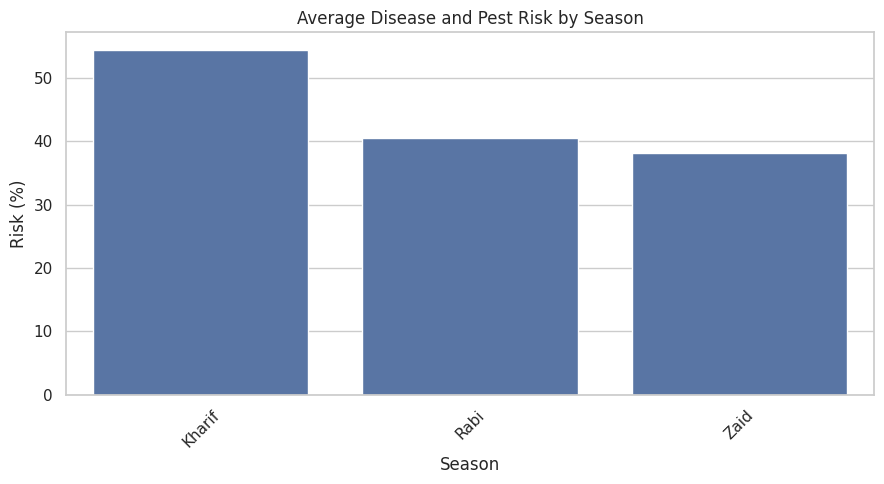

In [83]:
# Visualize disease/pest risk

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_risk.index,
    y=season_risk.values
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [84]:
# Create an overall seasonal performance summary

season_summary = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Total_Revenue=("Revenue_INR", "sum"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Temperature=("Avg_Temperature_C", "mean"),
    Average_Soil_Moisture=("Soil_Moisture_pct", "mean"),
    Average_Pest_Risk=("Disease_Pest_Risk_pct", "mean")
)

season_summary.round(2)

,Average_Yield,Total_Production,Total_Revenue,Total_Profit,Average_Water_Used,Average_Rainfall,Average_Temperature,Average_Soil_Moisture,Average_Pest_Risk
Season,,,,,,,,,
Kharif,5.64,82387.61,1264369200,318289158,6102.20,852.08,28.45,31.20,54.47
Rabi,5.08,67498.88,978682881,142670768,5846.99,436.00,23.49,24.05,40.48
Zaid,4.67,23098.35,308388111,-14734066,6419.89,299.42,31.04,19.17,38.22


In [85]:
# Select important numerical variables

numeric_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Revenue_INR",
    "Total_Cost_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

# Keep only columns that actually exist
available_columns = [
    col for col in numeric_columns
    if col in df.columns
]

correlation = df[available_columns].corr()

correlation.round(2)

,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,1.00,0.20,0.52,0.03,0.02,0.00,0.10,0.01,0.11,0.00,0.06,0.63
Avg_Temperature_C,0.20,1.00,0.08,0.01,0.01,0.00,0.03,0.04,0.01,0.02,0.01,0.25
Soil_Moisture_pct,0.52,0.08,1.00,0.01,0.00,0.02,0.08,0.00,0.09,0.00,0.03,0.38
Yield_Tonnes_Ha,0.03,0.01,0.01,1.00,0.89,-0.38,0.43,0.03,0.49,0.39,0.92,0.01
Production_Tonnes,0.02,0.01,0.00,0.89,1.00,-0.34,0.56,0.19,0.55,0.52,0.81,0.01
Market_Price_INR_Tonne,0.00,0.00,0.02,-0.38,-0.34,1.00,0.18,-0.02,0.23,-0.34,-0.37,-0.00
Revenue_INR,0.10,0.03,0.08,0.43,0.56,0.18,1.00,0.52,0.89,0.43,0.43,0.06
Total_Cost_INR,0.01,0.04,0.00,0.03,0.19,-0.02,0.52,1.00,0.07,0.58,0.02,0.01
Profit_INR,0.11,0.01,0.09,0.49,0.55,0.23,0.89,0.07,1.00,0.19,0.49,0.07
Water_Used_m3,0.00,0.02,0.00,0.39,0.52,-0.34,0.43,0.58,0.19,1.00,0.22,0.01


## 6. Relationship Analysis

Correlation analysis was used to examine relationships between environmental conditions, resource usage, agricultural productivity, economic outcomes, and disease/pest risk.

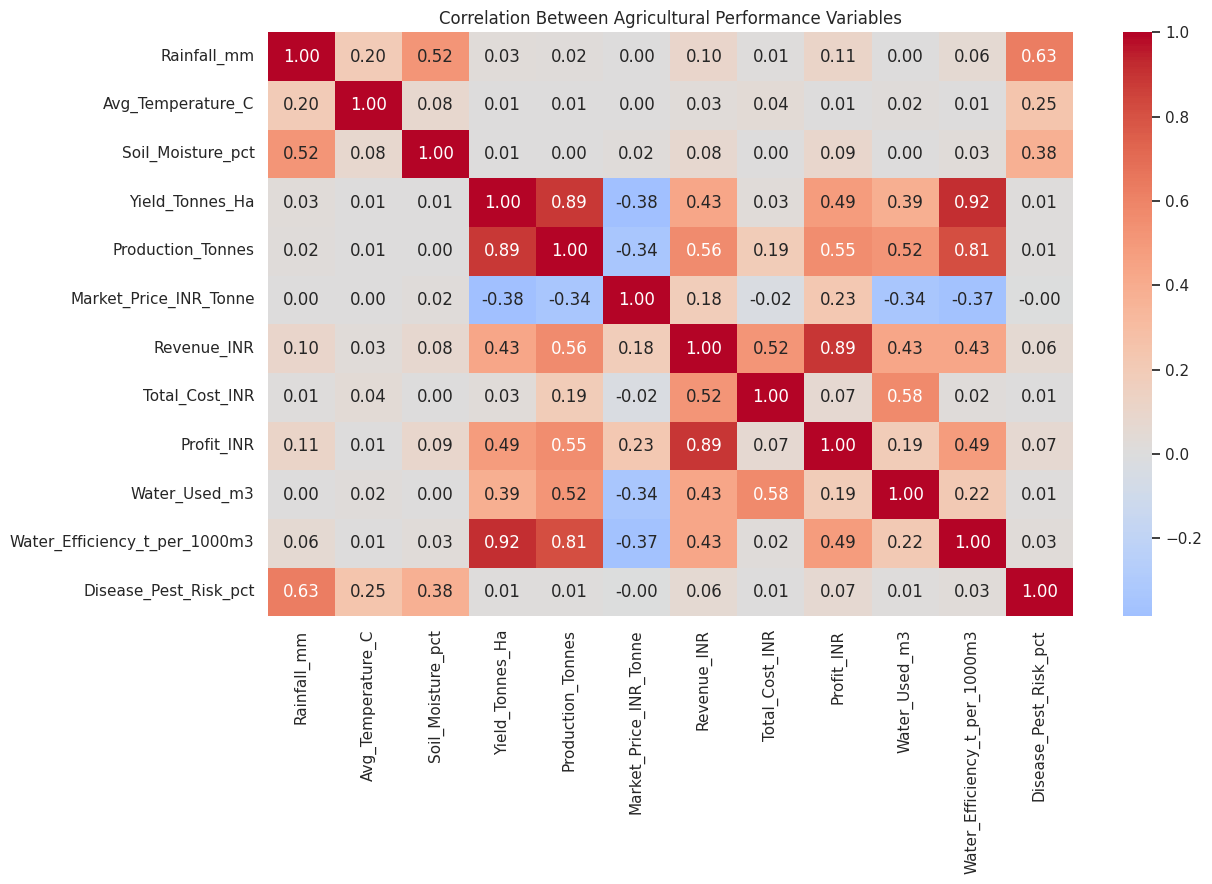

In [86]:
# Correlation heatmap

plt.figure(figsize=(13, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Agricultural Performance Variables")

plt.tight_layout()
plt.show()

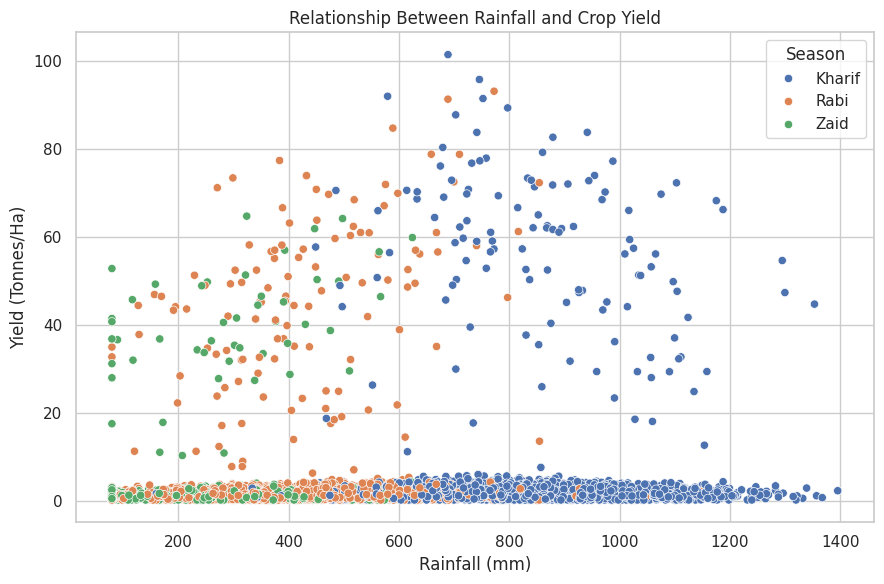

In [87]:
# Relationship between rainfall and crop yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Rainfall and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

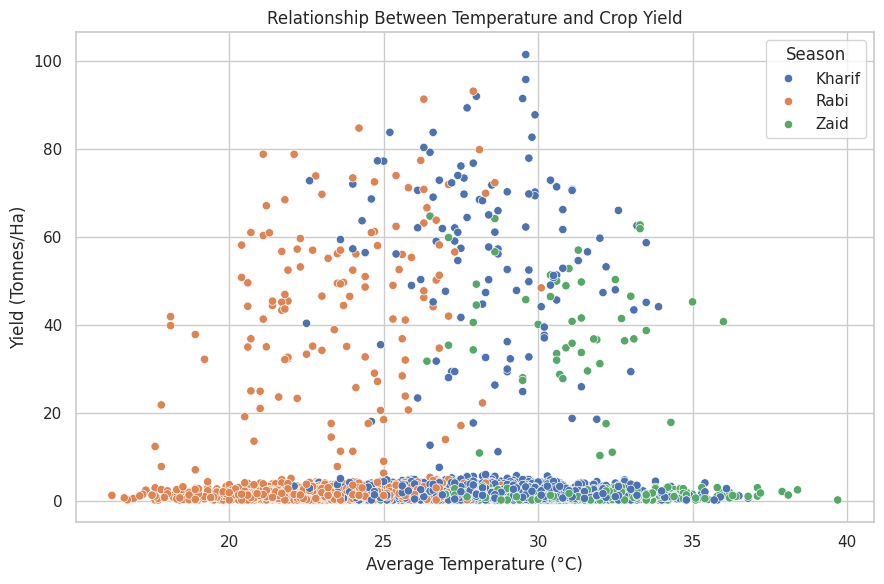

In [88]:
# Relationship between temperature and crop yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Temperature and Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

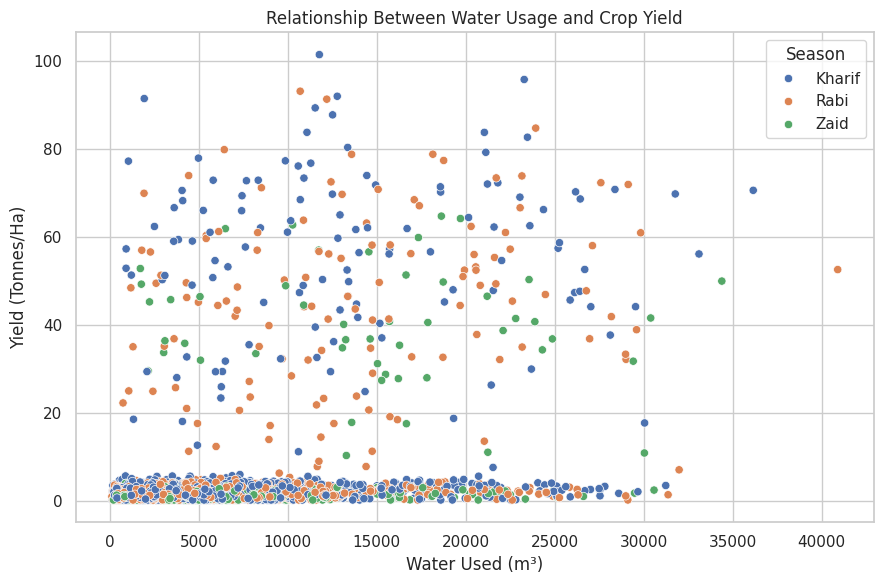

In [89]:
# Relationship between water usage and crop yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Water_Used_m3",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Relationship Between Water Usage and Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [90]:
# Average market price by season

season_price = df.groupby("Season")["Market_Price_INR_Tonne"].mean().sort_values(
    ascending=False
)

print("Average Market Price by Season:")
print(season_price)

Average Market Price by Season:
Season
Kharif    44850.906127
Rabi      44747.974800
Zaid      44212.033670
Name: Market_Price_INR_Tonne, dtype: float64


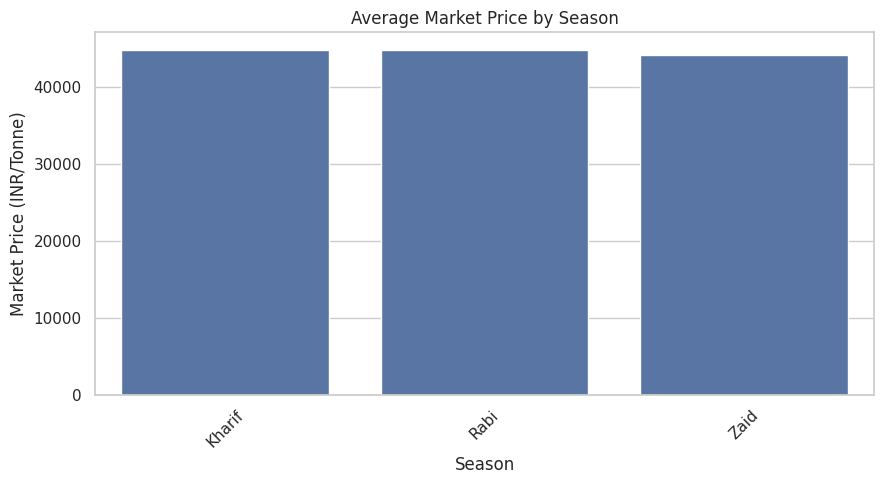

In [91]:
# Visualize average market price by season

plt.figure(figsize=(9, 5))

sns.barplot(
    x=season_price.index,
    y=season_price.values
)

plt.title("Average Market Price by Season")
plt.xlabel("Season")
plt.ylabel("Market Price (INR/Tonne)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
# Identify the season with the highest average yield

best_yield_season = season_yield.idxmax()
best_yield_value = season_yield.max()

print("Best Season based on Average Yield:")
print(best_yield_season)

print("\nAverage Yield:")
print(round(best_yield_value, 2), "Tonnes/Ha")

Best Season based on Average Yield:
Kharif

Average Yield:
5.64 Tonnes/Ha


In [93]:
# Identify the season with the highest average yield

best_yield_season = season_yield.idxmax()
best_yield_value = season_yield.max()

print("Best Season based on Average Yield:")
print(best_yield_season)

print("\nAverage Yield:")
print(round(best_yield_value, 2), "Tonnes/Ha")

Best Season based on Average Yield:
Kharif

Average Yield:
5.64 Tonnes/Ha


In [94]:
# Identify the season with the highest total profit

best_profit_season = season_profit.idxmax()
best_profit_value = season_profit.max()

print("Best Season based on Total Profit:")
print(best_profit_season)

print("\nTotal Profit:")
print(round(best_profit_value, 2), "INR")

Best Season based on Total Profit:
Kharif

Total Profit:
318289158 INR


In [95]:
# Identify the season with the highest production

best_production_season = season_production.idxmax()
best_production_value = season_production.max()

print("Highest Production Season:")
print(best_production_season)

print("\nTotal Production:")
print(round(best_production_value, 2), "Tonnes")

Highest Production Season:
Kharif

Total Production:
82387.61 Tonnes


In [96]:
# Rank seasons based on important performance indicators

ranking = season_summary.copy()

ranking["Yield_Rank"] = ranking["Average_Yield"].rank(
    ascending=False
)

ranking["Production_Rank"] = ranking["Total_Production"].rank(
    ascending=False
)

ranking["Profit_Rank"] = ranking["Total_Profit"].rank(
    ascending=False
)

ranking["Water_Usage_Rank"] = ranking["Average_Water_Used"].rank(
    ascending=True
)

ranking.round(2)

,Average_Yield,Total_Production,Total_Revenue,Total_Profit,Average_Water_Used,Average_Rainfall,Average_Temperature,Average_Soil_Moisture,Average_Pest_Risk,Yield_Rank,Production_Rank,Profit_Rank,Water_Usage_Rank
Season,,,,,,,,,,,,,
Kharif,5.64,82387.61,1264369200,318289158,6102.20,852.08,28.45,31.20,54.47,1.0,1.0,1.0,2.0
Rabi,5.08,67498.88,978682881,142670768,5846.99,436.00,23.49,24.05,40.48,2.0,2.0,2.0,1.0
Zaid,4.67,23098.35,308388111,-14734066,6419.89,299.42,31.04,19.17,38.22,3.0,3.0,3.0,3.0


## 7. Key Findings

The analysis was used to identify the strongest-performing season and important differences across seasonal agricultural conditions.

The findings are interpreted based on the observed patterns in the dataset.

In [97]:
# Automatically generate basic findings

highest_yield_season = season_summary["Average_Yield"].idxmax()
highest_production_season = season_summary["Total_Production"].idxmax()
highest_profit_season = season_summary["Total_Profit"].idxmax()
lowest_water_season = season_summary["Average_Water_Used"].idxmin()
highest_risk_season = season_summary["Average_Pest_Risk"].idxmax()

print("KEY FINDINGS")
print("=" * 50)

print(f"1. Highest average yield: {highest_yield_season}")
print(f"2. Highest total production: {highest_production_season}")
print(f"3. Highest total profit: {highest_profit_season}")
print(f"4. Lowest average water usage: {lowest_water_season}")
print(f"5. Highest disease/pest risk: {highest_risk_season}")

KEY FINDINGS
1. Highest average yield: Kharif
2. Highest total production: Kharif
3. Highest total profit: Kharif
4. Lowest average water usage: Rabi
5. Highest disease/pest risk: Kharif


In [98]:
# Final dataset information after cleaning

print("FINAL DATASET SUMMARY")
print("=" * 40)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate Rows:", df.duplicated().sum())
print("Missing Values:", df.isnull().sum().sum())

FINAL DATASET SUMMARY
Rows: 4000
Columns: 28
Duplicate Rows: 0
Missing Values: 120


In [99]:
# Overall Seasonal Performance Dashboard

dashboard = season_summary[[
    "Average_Yield",
    "Total_Production",
    "Total_Revenue",
    "Total_Profit",
    "Average_Water_Used",
    "Average_Rainfall",
    "Average_Temperature",
    "Average_Soil_Moisture",
    "Average_Pest_Risk"
]].round(2)

dashboard

,Average_Yield,Total_Production,Total_Revenue,Total_Profit,Average_Water_Used,Average_Rainfall,Average_Temperature,Average_Soil_Moisture,Average_Pest_Risk
Season,,,,,,,,,
Kharif,5.64,82387.61,1264369200,318289158,6102.20,852.08,28.45,31.20,54.47
Rabi,5.08,67498.88,978682881,142670768,5846.99,436.00,23.49,24.05,40.48
Zaid,4.67,23098.35,308388111,-14734066,6419.89,299.42,31.04,19.17,38.22


In [101]:
# Compare important agricultural performance indicators across seasons

comparison = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "sum",
    "Revenue_INR": "sum",
    "Profit_INR": "sum",
    "Water_Used_m3": "mean"
}).round(2)

comparison

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3
Season,,,,,
Kharif,5.64,82387.61,1264369200,318289158,6102.20
Rabi,5.08,67498.88,978682881,142670768,5846.99
Zaid,4.67,23098.35,308388111,-14734066,6419.89


In [102]:
# Calculate normalized performance scores

score_data = season_summary[[
    "Average_Yield",
    "Total_Production",
    "Total_Revenue",
    "Total_Profit"
]].copy()

score_data["Overall_Score"] = (
    score_data["Average_Yield"].rank(pct=True) +
    score_data["Total_Production"].rank(pct=True) +
    score_data["Total_Revenue"].rank(pct=True) +
    score_data["Total_Profit"].rank(pct=True)
) / 4

score_data = score_data.sort_values(
    "Overall_Score",
    ascending=False
)

score_data.round(3)

,Average_Yield,Total_Production,Total_Revenue,Total_Profit,Overall_Score
Season,,,,,
Kharif,5.644,82387.61,1264369200,318289158,1.000
Rabi,5.080,67498.88,978682881,142670768,0.667
Zaid,4.666,23098.35,308388111,-14734066,0.333


In [103]:
# Identify the best overall performing season

best_overall_season = score_data["Overall_Score"].idxmax()

print("Best Overall Performing Season:")
print(best_overall_season)

print("\nOverall Performance Score:")
print(round(score_data.loc[best_overall_season, "Overall_Score"], 3))

Best Overall Performing Season:
Kharif

Overall Performance Score:
1.0


## 8. Recommendations

The recommendations are based on the patterns identified through seasonal comparisons, resource usage analysis, environmental analysis, and economic performance.

In [104]:
# Generate data-driven recommendations

print("DATA-DRIVEN RECOMMENDATIONS")
print("=" * 55)

print(f"1. Focus on practices used during {highest_yield_season}, "
      "as it recorded the highest average crop yield.")

print(f"2. Consider the conditions of {highest_profit_season} "
      "for improving agricultural profitability.")

print(f"3. Water management practices should be studied in "
      f"{lowest_water_season}, which showed the lowest average water usage.")

print(f"4. Additional crop protection measures may be useful during "
      f"{highest_risk_season}, which showed the highest disease/pest risk.")

print("5. Seasonal environmental conditions such as rainfall, "
      "temperature and soil moisture should be considered when planning crops.")

print("6. Resource usage and economic outcomes should be evaluated "
      "together rather than focusing only on production.")

DATA-DRIVEN RECOMMENDATIONS
1. Focus on practices used during Kharif, as it recorded the highest average crop yield.
2. Consider the conditions of Kharif for improving agricultural profitability.
3. Water management practices should be studied in Rabi, which showed the lowest average water usage.
4. Additional crop protection measures may be useful during Kharif, which showed the highest disease/pest risk.
5. Seasonal environmental conditions such as rainfall, temperature and soil moisture should be considered when planning crops.
6. Resource usage and economic outcomes should be evaluated together rather than focusing only on production.


## 9. Conclusion

The analysis demonstrates that agricultural performance varies across seasons in terms of productivity, resource utilization, environmental conditions, and economic outcomes.

Among the analyzed seasons, Kharif emerged as the strongest overall performing season based on the combined performance indicators used in this analysis.

The findings highlight the importance of considering seasonal conditions, resource management, productivity, and profitability together when making agricultural planning decisions.